# **Removing Duplicates**


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [23]:
!pip install pandas
!pip install scikit-learn

In [44]:
!pip install matplotlib
!pip install numpy
!matplotlib inline
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 143.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 157.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 168.9 MB/s eta 0:00:00
/bin/bash: line 1: matplotlib: command not found


### Step 1: Import Required Libraries


In [24]:
import pandas as pd
import sklearn

In [25]:
from sklearn.preprocessing import MinMaxScaler

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [26]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [27]:
# Count duplicate rows across all columns
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [28]:
# Extract duplicate rows
duplicates = df[df.duplicated()]

# Display first few duplicates
print("First few duplicate rows:")
print(duplicates.head())

First few duplicate rows:
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmired, OfficeStackSyncHaveWork

### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [29]:
df_no_duplicates = df.drop_duplicates()

print("Original dataset shape:", df.shape)
print("After removing duplicates:", df_no_duplicates.shape)

Original dataset shape: (65437, 114)
After removing duplicates: (65437, 114)


In [30]:
df_no_duplicates = df.drop_duplicates()

In [31]:
# Count duplicate rows again
remaining_duplicates = df_no_duplicates.duplicated().sum()
print("Number of duplicate rows after removal:", remaining_duplicates)

Number of duplicate rows after removal: 0


### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [32]:
# Count missing values for each column
missing_values = df.isnull().sum()

# Display the first 20 columns with missing values
print(missing_values.head(20))

ResponseId               0
MainBranch               0
Age                      0
Employment               0
RemoteWork           10631
Check                    0
CodingActivities     10971
EdLevel               4653
LearnCode             4949
LearnCodeOnline      16200
TechDoc              24540
YearsCode             5568
YearsCodePro         13827
DevType               5992
OrgSize              17957
PurchaseInfluence    18031
BuyNewTool           20256
BuildvsBuy           22079
TechEndorse          21769
Country               6507
dtype: int64


In [33]:
total_missing = df.isnull().sum().sum()
print("Total missing values in dataset:", total_missing)

# Columns with at least one missing value
missing_columns = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_columns)

Total missing values in dataset: 2890957
Columns with missing values:
RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


In [34]:
# Percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False).head(20))

AINextMuch less integrated       98.245641
AINextLess integrated            96.401119
AINextNo change                  80.900714
AINextMuch more integrated       79.464217
EmbeddedAdmired                  74.428840
EmbeddedWantToWorkWith           73.103901
EmbeddedHaveWorkedWith           66.052845
ConvertedCompYearly              64.186928
AIToolNot interested in Using    62.690832
AINextMore integrated            62.669438
Knowledge_9                      57.768541
Frequency_3                      57.653927
Knowledge_8                      57.580574
ProfessionalTech                 57.571405
Knowledge_7                      57.550010
Knowledge_6                      57.418586
Knowledge_5                      57.394135
Knowledge_2                      57.178660
Knowledge_4                      57.164907
Knowledge_3                      57.065575
dtype: float64


In [35]:
# Count missing values in EdLevel
missing_edlevel = df["EdLevel"].isnull().sum()
print("Missing values in EdLevel:", missing_edlevel)

Missing values in EdLevel: 4653


In [36]:
most_frequent_edlevel = df["EdLevel"].mode()[0]
print("Most frequent value in EdLevel:", most_frequent_edlevel)

Most frequent value in EdLevel: Bachelor’s degree (B.A., B.S., B.Eng., etc.)


In [37]:
# Find the most frequent value in EdLevel LearnCode     
frequent_learncode = df["LearnCode"].mode()[0]
print("Most frequent value in LearnCode:", frequent_learncode)

Most frequent value in LearnCode: Other online resources (e.g., videos, blogs, forum, online community)


In [38]:
# Fill missing values with the most frequent value
df["EdLevel"].fillna(most_frequent_edlevel, inplace=True)

# Verify again
print("Missing values in EdLevel after imputation:", df["EdLevel"].isnull().sum())

Missing values in EdLevel after imputation: 4653


/tmp/ipykernel_798/2341423736.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["EdLevel"].fillna(most_frequent_edlevel, inplace=True)


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [39]:
# Check basic info about compensation column
print(df["ConvertedCompYearly"].describe())

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


In [40]:
# Check basic info about compensation column
print(df["ConvertedCompYearly"].describe())

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


In [41]:
# Count missing values
missing_comp = df["ConvertedCompYearly"].isnull().sum()
print("Missing compensation values:", missing_comp)

# # Optionally fill missing values with median (robust to outliers)
df["ConvertedCompYearly"].fillna(df["ConvertedCompYearly"].median(), inplace=True)

Missing compensation values: 42002


/tmp/ipykernel_798/2292408678.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["ConvertedCompYearly"].fillna(df["ConvertedCompYearly"].median(), inplace=True)


0        65000.0
1        65000.0
2        65000.0
3        65000.0
4        65000.0
          ...   
65432    65000.0
65433    65000.0
65434    65000.0
65435    65000.0
65436    65000.0
Name: ConvertedCompYearly, Length: 65437, dtype: float64

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["Compensation_Normalized"] = scaler.fit_transform(df[["ConvertedCompYearly"]])

# Preview normalized values
df[["ConvertedCompYearly", "Compensation_Normalized"]].head()

,ConvertedCompYearly,Compensation_Normalized
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


Text(0, 0.5, 'Frequency')

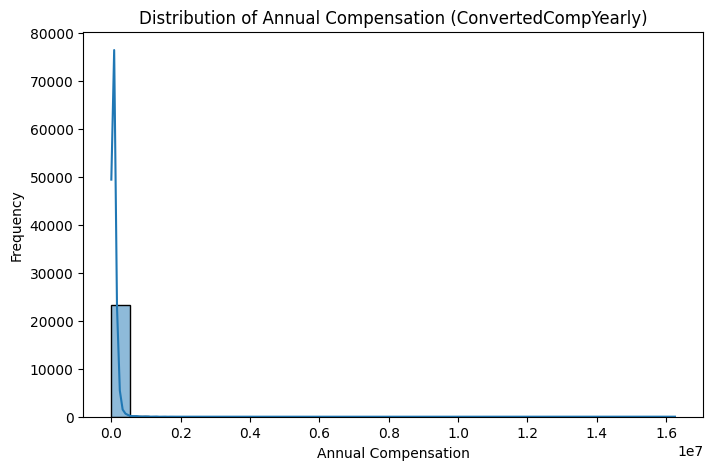

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["ConvertedCompYearly"], bins=30, kde=True)
plt.title("Distribution of Annual Compensation (ConvertedCompYearly)")
plt.xlabel("Annual Compensation")
plt.ylabel("Frequency")

### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'),
  Text(1, 0, 'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)'),
  Text(2, 0, 'Some college/university study without earning a degree'),
  Text(3, 0, 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)'),
  Text(4, 0, 'Professional degree (JD, MD, Ph.D, Ed.D, etc.)'),
  Text(5, 0, 'Associate degree (A.A., A.S., etc.)'),
  Text(6, 0, 'Primary/elementary school'),
  Text(7, 0, 'Something else')])

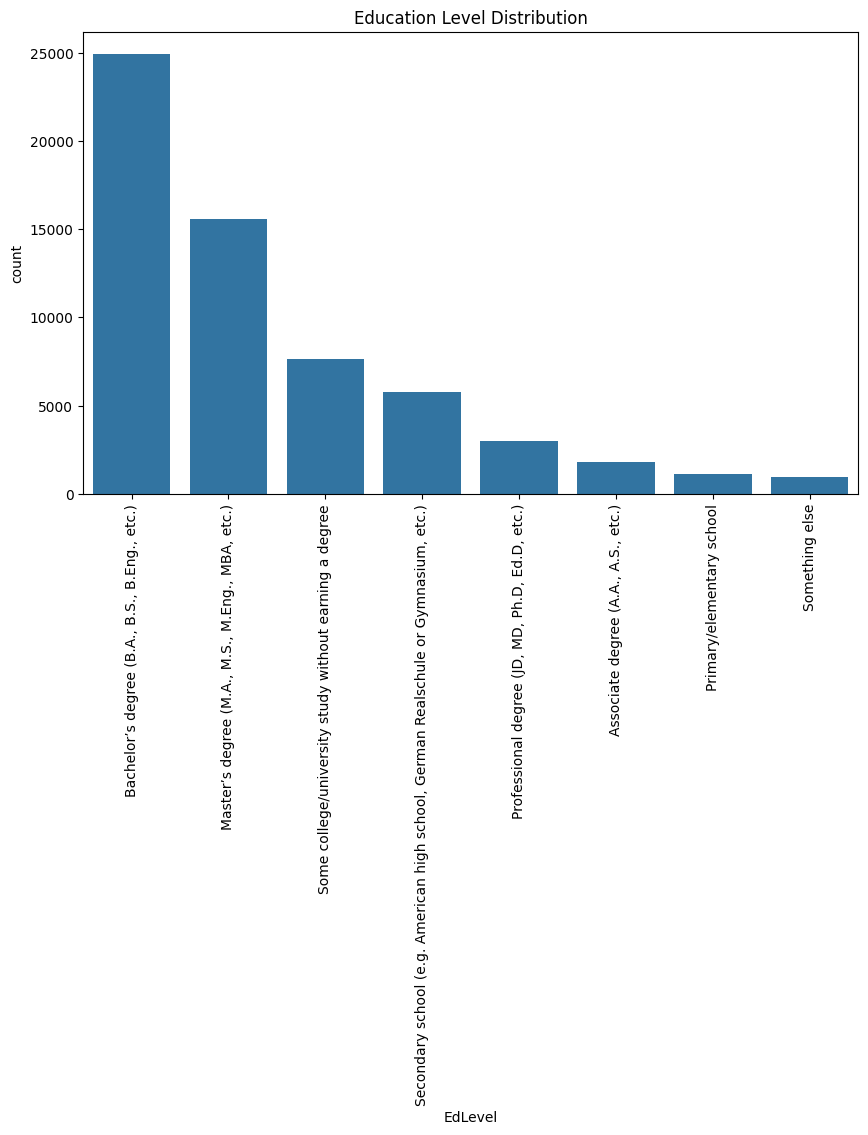

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_no_duplicates, x="EdLevel", order=df_no_duplicates["EdLevel"].value_counts().index)
plt.title("Education Level Distribution")
plt.xticks(rotation=90)